In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## Step 3: Train-Test-Split

In [4]:
df = pd.read_csv("step3_clean.csv")

In [5]:
X = df.drop(columns=["SeriousDlqin2yrs"])
Y = df["SeriousDlqin2yrs"]

In [6]:
print(f"X size: {X.shape}")
print(f"Y size: {Y.shape}")

X size: (120170, 10)
Y size: (120170,)


In [7]:
Y.value_counts()

SeriousDlqin2yrs
0    111815
1      8355
Name: count, dtype: int64

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, 
                                                   random_state=42)

In [9]:
print(f"X_train size: {X_train.shape}")
print(f"Y_train size: {Y_train.shape}")
print(f"X_test size: {X_test.shape}")
print(f"Y_test size: {Y_test.shape}")

X_train size: (96136, 10)
Y_train size: (96136,)
X_test size: (24034, 10)
Y_test size: (24034,)


In [10]:
print(f"\nDefault rate — full:  {Y.mean() * 100:.3f}%")
print(f"Default rate — train: {Y_train.mean() * 100:.3f}%")
print(f"Default rate — test:  {Y_test.mean() * 100:.3f}%")
print(f"Defaulters in train: {Y_train.sum():,} | in test: {Y_test.sum():,}")


Default rate — full:  6.953%
Default rate — train: 6.953%
Default rate — test:  6.953%
Defaulters in train: 6,684 | in test: 1,671


## Step 4: Outlier Detection 

### Age treatment

In [11]:
count = (X_train["age"] == 0).sum()

if count != 0:
    print(f"There are {count} rows having age entry 0 in training data.")
    keep = X_train["age"] > 0
    X_train, Y_train = X_train[keep], Y_train[keep]

if (X_test["age"] == 0).any():
    print(f"There are {(X_test["age"] == 0).count()} rows having age entry 0 in testing data.")
    X_test.loc[X_train["age"] == 0, "age"] = X_train["age"].min()

There are 1 rows having age entry 0 in training data.


In [12]:
X_train.shape, Y_train.shape

((96135, 10), (96135,))

In [13]:
X_train.head(5)

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
63534,0.178471,59,0,0.173216,4300.0,9,0,0,0,4.0
28637,0.099706,57,0,0.309601,8300.0,4,0,1,0,1.0
33331,0.384630,28,1,551.500000,1.0,4,0,1,0,0.0
83229,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0
27253,0.012433,67,0,0.182222,7885.0,11,0,1,0,0.0


In [14]:
from sklearn.metrics import classification_report

def validate(X, Y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ])
    grid_lr = GridSearchCV(lr, {'lr__C': [0.01, 0.1, 1, 10]},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
    grid_lr.fit(X, Y)

    dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    grid_dt = GridSearchCV(dt, {'max_depth': [4, 5, 6, 8],
                                'min_samples_leaf': [50, 100, 200]},
                           cv=cv, scoring='roc_auc', n_jobs=-1)
    grid_dt.fit(X, Y)

    print(f"LogReg: {grid_lr.best_score_:.4f} {grid_lr.best_params_}   "
          f"DT: {grid_dt.best_score_:.4f} {grid_dt.best_params_}")

    # classification reports from CV predictions (train only — no test contact)
    for name, est in [('LogReg', grid_lr.best_estimator_), ('DecisionTree', grid_dt.best_estimator_)]:
        pred = cross_val_predict(est, X, Y, cv=cv, n_jobs=-1)
        print(f"--- {name} (CV predictions) ---")
        print(classification_report(Y, pred))

### Delinquencies treatment

In [15]:
validate(X_train, Y_train)

LogReg: 0.7974 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     89451
           1       0.22      0.62      0.32      6684

    accuracy                           0.82     96135
   macro avg       0.59      0.73      0.61     96135
weighted avg       0.92      0.82      0.85     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



In [16]:
df.loc[X_train[X_train["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98])].index, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    67
0    50
Name: count, dtype: int64

In [17]:
X_train["is_coded"] = X_train["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98]).astype(int)
X_test["is_coded"] = X_test["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98]).astype(int)

In [18]:
del_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
          "NumberOfTime60-89DaysPastDueNotWorse",
          "NumberOfTimes90DaysLate"]

for col in del_cols:
    cap = X_train.loc[X_train[col] < 90, col].max()
    X_train[col] = X_train[col].clip(upper=cap)
    X_test[col] = X_test[col].clip(upper=cap)

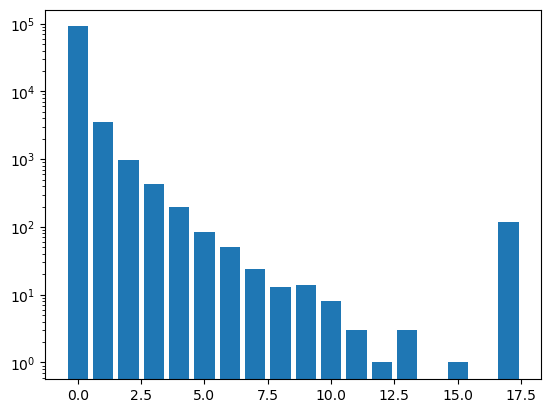

In [19]:
col = X_train["NumberOfTimes90DaysLate"].value_counts().sort_index()
plt.bar(col.index , col.values)
plt.yscale("log")

In [20]:
validate(X_train, Y_train)

LogReg: 0.8128 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     89451
           1       0.26      0.62      0.37      6684

    accuracy                           0.85     96135
   macro avg       0.62      0.74      0.64     96135
weighted avg       0.92      0.85      0.88     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



In [21]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_coded
63534,0.178471,59,0,0.173216,4300.0,9,0,0,0,4.0,0
28637,0.099706,57,0,0.309601,8300.0,4,0,1,0,1.0,0
33331,0.384630,28,1,551.500000,1.0,4,0,1,0,0.0,0
83229,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0,0
27253,0.012433,67,0,0.182222,7885.0,11,0,1,0,0.0,0


### Revolving Utilization treatment

In [22]:
validate(X_train, Y_train)

LogReg: 0.8128 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     89451
           1       0.26      0.62      0.37      6684

    accuracy                           0.85     96135
   macro avg       0.62      0.74      0.64     96135
weighted avg       0.92      0.85      0.88     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



C:\Users\shashank\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Count'>

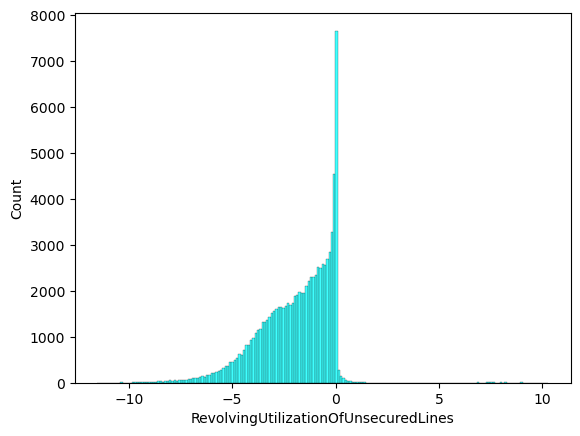

In [23]:
sns.histplot(np.log(X_train["RevolvingUtilizationOfUnsecuredLines"]), color="cyan")

In [24]:
df["RevolvingUtilizationOfUnsecuredLines"].describe()

count    120170.000000
mean          5.904284
std         257.146497
min           0.000000
25%           0.035149
50%           0.177261
75%           0.578862
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [25]:
np.percentile(df["RevolvingUtilizationOfUnsecuredLines"], 99)

np.float64(1.09001646762)

In [26]:
np.percentile(df["RevolvingUtilizationOfUnsecuredLines"], 99.8)

np.float64(2.224514439449955)

In [27]:
np.percentile(df["RevolvingUtilizationOfUnsecuredLines"], 99.9)

np.float64(1135.733000000866)

In [28]:
df.loc[df["RevolvingUtilizationOfUnsecuredLines"]>3, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    185
1     25
Name: count, dtype: int64

In [29]:
df.loc[df["RevolvingUtilizationOfUnsecuredLines"]>1, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    1743
1    1030
Name: count, dtype: int64

In [30]:
cap = X_train["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99)
X_train["RevolvingUtilizationOfUnsecuredLines"] = X_train["RevolvingUtilizationOfUnsecuredLines"].clip(upper=cap)
X_test["RevolvingUtilizationOfUnsecuredLines"] = X_test["RevolvingUtilizationOfUnsecuredLines"].clip(upper=cap)

In [31]:
X_train["RevolvingUtilizationOfUnsecuredLines"].describe()

count    96135.000000
mean         0.331372
std          0.349897
min          0.000000
25%          0.035173
50%          0.177563
75%          0.579314
max          1.091408
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [32]:
validate(X_train, Y_train)

LogReg: 0.8490 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.84     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



### Debt Ratio Treatment

In [33]:
validate(X_train, Y_train)

LogReg: 0.8490 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.84     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



In [34]:
np.percentile(X_train['DebtRatio'], 50)

np.float64(0.296547821)

In [35]:
np.percentile(X_train["DebtRatio"], 80)

np.float64(0.5433182031999999)

In [36]:
np.percentile(X_train["DebtRatio"], 98)

np.float64(4.513245351039687)

In [37]:
np.percentile(X_train["DebtRatio"], 98.5)

np.float64(47.99000000000524)

In [38]:
np.percentile(X_train["DebtRatio"], 99)

np.float64(623.9800000000105)

In [39]:
X_train.loc[X_train["DebtRatio"] > 4.513245351039687, "MonthlyIncome"].unique()

array([1.0000e+00, 0.0000e+00, 1.5000e+02, 2.5000e+02, 2.0000e+02,
       7.7800e+02, 5.2700e+02, 3.7500e+03, 3.3333e+04, 2.5800e+04,
       9.3880e+03, 4.0000e+00, 3.5000e+03, 1.0000e+02, 5.2000e+02,
       3.0000e+02, 6.3200e+02, 2.9500e+03, 2.1850e+03, 5.8100e+02,
       2.1000e+01, 1.5000e+03, 2.0000e+03, 8.7600e+02, 5.3330e+03,
       4.1700e+02, 4.0000e+02, 4.3600e+02, 9.0000e+00, 1.4000e+03,
       4.2500e+02, 1.0700e+02, 6.5000e+02, 5.0000e+02, 3.7200e+02,
       2.5000e+03, 4.6110e+03, 3.8000e+02, 3.5100e+02, 1.0000e+03,
       6.6200e+02, 1.0500e+02, 6.0000e+02, 3.9100e+02, 1.5010e+03,
       1.0000e+01, 7.0000e+01, 5.5000e+01, 8.3400e+02, 2.0000e+00,
       3.3330e+03, 2.2000e+03, 5.0000e+01, 3.3300e+02, 4.0000e+03,
       3.7000e+03, 2.6010e+03, 4.7250e+03, 6.1660e+03, 4.4400e+02,
       1.0417e+04, 3.0700e+02, 4.5000e+02, 1.0100e+02, 9.0000e+02,
       2.4000e+03, 1.5100e+02, 3.0000e+03, 9.2000e+03, 5.0000e+00,
       1.4000e+04, 2.0100e+02, 1.8000e+03, 5.9930e+03, 1.8070e

In [40]:
X_train.loc[X_train["DebtRatio"] > 47.99000000000524, "MonthlyIncome"].unique()

array([1.000e+00, 0.000e+00, 4.000e+00, 2.100e+01, 9.000e+00, 1.000e+01,
       5.500e+01, 5.000e+01, 2.601e+03, 2.000e+00, 5.000e+00, 2.700e+01,
       1.200e+03, 4.010e+02, 1.100e+01, 1.000e+02, 7.223e+03, 5.600e+01,
       4.000e+01, 1.500e+01])

In [41]:
X_train.loc[X_train["DebtRatio"] > 623.9800000000105, "MonthlyIncome"].unique()

array([0., 1.])

C:\Users\shashank\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='DebtRatio', ylabel='Count'>

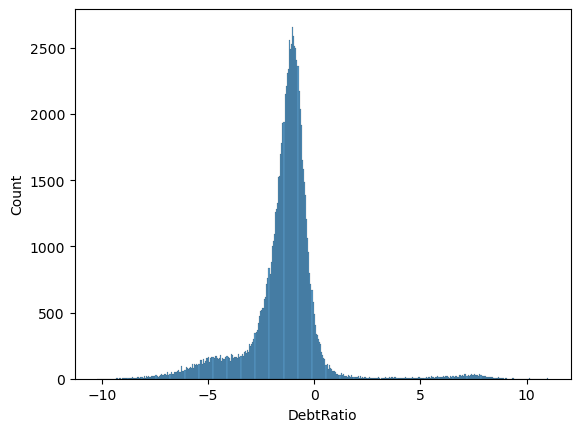

In [42]:
sns.histplot(np.log(X_train["DebtRatio"]))

In [43]:
print(df.loc[X_train[X_train["DebtRatio"] > 4.5132].index, "SeriousDlqin2yrs"].value_counts())
print("4.47% defaulter.")

SeriousDlqin2yrs
0    1837
1      86
Name: count, dtype: int64
4.47% defaulter.


In [44]:
print(df.loc[X_train[X_train["DebtRatio"] > 623.98].index, "SeriousDlqin2yrs"].value_counts())
print("4.36% defaulter.")

SeriousDlqin2yrs
0    920
1     42
Name: count, dtype: int64
4.36% defaulter.


In [45]:
print(df.loc[X_train[X_train["DebtRatio"] <= 1].index, "SeriousDlqin2yrs"].value_counts())
print("6.76% defaulter.")

SeriousDlqin2yrs
0    84209
1     6101
Name: count, dtype: int64
6.76% defaulter.


In [46]:
print(df.loc[X_train[X_train["DebtRatio"] <= 0.5].index, "SeriousDlqin2yrs"].value_counts())
print("6.097% defaulter.")

SeriousDlqin2yrs
0    69081
1     4486
Name: count, dtype: int64
6.097% defaulter.


In [47]:
print(df.loc[X_train[(X_train["DebtRatio"] > 0.5) & (X_train["DebtRatio"] <1)].index, "SeriousDlqin2yrs"].value_counts())
print("9.652% defaulter")

SeriousDlqin2yrs
0    15108
1     1614
Name: count, dtype: int64
9.652% defaulter


In [48]:
from sklearn.preprocessing import KBinsDiscretizer

kbin = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

X_train['dr_bin'] = kbin.fit_transform(X_train[['DebtRatio']])   # learns edges from train
X_test['dr_bin']  = kbin.transform(X_test[['DebtRatio']]) 

In [49]:
X_tt = X_train
dummies = pd.get_dummies(X_tt['dr_bin'], prefix='dr').astype(int)

In [50]:
X_ttt = X_test
dr_train = pd.get_dummies(X_tt['dr_bin'], prefix='dr').astype(int)
dr_test = pd.get_dummies(X_ttt['dr_bin'], prefix='dr').astype(int)

# forces test's table to have exactly train's columns, in the same order, the missing column value is fillied with zero
dr_test = dr_test.reindex(columns=dr_train.columns, fill_value=0)  

In [51]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_coded,dr_bin
63534,0.178471,59,0,0.173216,4300.0,9,0,0,0,4.0,0,2.0
28637,0.099706,57,0,0.309601,8300.0,4,0,1,0,1.0,0,5.0
33331,0.384630,28,1,551.500000,1.0,4,0,1,0,0.0,0,9.0
83229,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0,0,9.0
27253,0.012433,67,0,0.182222,7885.0,11,0,1,0,0.0,0,3.0


In [52]:
validate(X_tt, Y_train)

LogReg: 0.8489 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.84     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



In [51]:
df[(df["DebtRatio"] > 1) & (df["DebtRatio"] <= 10)]["SeriousDlqin2yrs"].value_counts() * 100/sum(df[(df["DebtRatio"] > 1) & (df["DebtRatio"] <= 10)]["SeriousDlqin2yrs"].value_counts())

SeriousDlqin2yrs
0    87.36103
1    12.63897
Name: count, dtype: float64

In [52]:
df[df["DebtRatio"] > 10]["SeriousDlqin2yrs"].value_counts() * 100/sum(df[df["DebtRatio"] > 10]["SeriousDlqin2yrs"].value_counts())

SeriousDlqin2yrs
0    95.963913
1     4.036087
Name: count, dtype: float64

### Monthly Income

In [53]:
validate(X_train, Y_train)

LogReg: 0.8489 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.84     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



In [54]:
np.percentile(X_train["MonthlyIncome"], 99)

np.float64(25000.0)

In [55]:
np.percentile(X_train["MonthlyIncome"], 99.7)

np.float64(44000.0)

In [56]:
df.loc[X_train[X_train["MonthlyIncome"] <= 1].index, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    1699
1      64
Name: count, dtype: int64

In [57]:
df.loc[X_train[(X_train["MonthlyIncome"] > 1) & (X_train["MonthlyIncome"] <= 100)].index, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    52
1     1
Name: count, dtype: int64

In [58]:
df.loc[X_train[(X_train["MonthlyIncome"] > 100) & (X_train["MonthlyIncome"] <= 999)].index, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    1545
1     110
Name: count, dtype: int64

In [59]:
df.loc[X_train[X_train["MonthlyIncome"] < 1257].index, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    4357
1     300
Name: count, dtype: int64

C:\Users\shashank\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

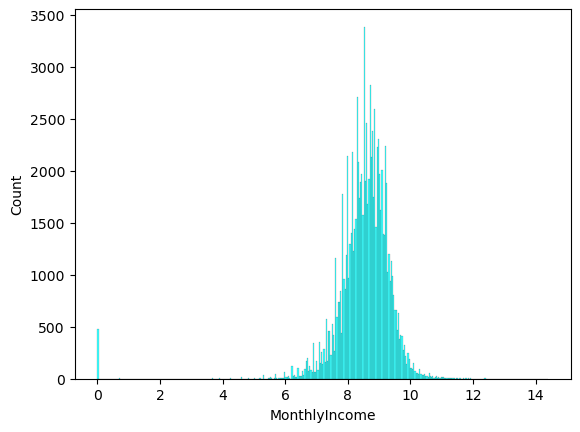

In [60]:
sns.histplot(np.log(X_train["MonthlyIncome"]), color="cyan")

In [61]:
df["MonthlyIncome"].describe()

count    1.201700e+05
mean     6.675098e+03
std      1.438958e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.250000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [62]:
X_train["MonthlyIncome"].value_counts().sort_index()

MonthlyIncome
0.0          1282
1.0           481
2.0             5
4.0             2
5.0             2
             ... 
702500.0        1
835040.0        1
1072500.0       1
1560100.0       1
1794060.0       1
Name: count, Length: 12636, dtype: int64

In [63]:
df.loc[df["MonthlyIncome"] < 1000, "SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    4124
1     218
Name: count, dtype: int64

In [64]:
# flag first (before cap/log change the values)
X_train['low_income_flag'] = (X_train['MonthlyIncome'] <= 1).astype(int)
X_test['low_income_flag'] = (X_test['MonthlyIncome'] <= 1).astype(int)

In [65]:
cap = X_train["MonthlyIncome"].quantile(0.99)
X_train["MonthlyIncome"] = X_train["MonthlyIncome"].clip(upper=cap)
X_test["MonthlyIncome"] = X_test["MonthlyIncome"].clip(upper=cap)

In [66]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_coded,dr_bin,low_income_flag
63534,0.178471,59,0,0.173216,4300.0,9,0,0,0,4.0,0,2.0,0
28637,0.099706,57,0,0.309601,8300.0,4,0,1,0,1.0,0,5.0,0
33331,0.384630,28,1,551.500000,1.0,4,0,1,0,0.0,0,9.0,1
83229,0.230493,60,0,1.017328,3000.0,10,0,1,0,0.0,0,9.0,0
27253,0.012433,67,0,0.182222,7885.0,11,0,1,0,0.0,0,3.0,0


In [67]:
X_train["MonthlyIncome"].describe()

count    96135.000000
mean      6347.391221
std       4344.242155
min          0.000000
25%       3400.000000
50%       5400.000000
75%       8250.000000
max      25000.000000
Name: MonthlyIncome, dtype: float64

In [68]:
validate(X_train, Y_train)

LogReg: 0.8500 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.85     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



## Step 5: Feature Engineering 

In [69]:
X_train.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'is_coded', 'dr_bin', 'low_income_flag'],
      dtype='object')

In [70]:
X_train['MonthlyIncome'] = np.log1p(X_train['MonthlyIncome'])
X_test['MonthlyIncome']  = np.log1p(X_test['MonthlyIncome'])

In [71]:
validate(X_train, Y_train)

LogReg: 0.8503 {'lr__C': 10}   DT: 0.8453 {'max_depth': 8, 'min_samples_leaf': 200}
--- LogReg (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     89451
           1       0.22      0.73      0.34      6684

    accuracy                           0.80     96135
   macro avg       0.60      0.77      0.61     96135
weighted avg       0.92      0.80      0.85     96135

--- DecisionTree (CV predictions) ---
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     89451
           1       0.21      0.76      0.32      6684

    accuracy                           0.78     96135
   macro avg       0.59      0.77      0.60     96135
weighted avg       0.92      0.78      0.83     96135



## Step 6: Feature Selection

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Z = StandardScaler().fit_transform(X_train)
vif = pd.Series([variance_inflation_factor(Z, i) for i in range(Z.shape[1])],
                index=X_train.columns)
print(vif.round(2).sort_values(ascending=False))

is_coded                                3.30
NumberOfTimes90DaysLate                 2.84
NumberOfTime60-89DaysPastDueNotWorse    2.69
NumberOfTime30-59DaysPastDueNotWorse    1.63
dr_bin                                  1.58
NumberRealEstateLoansOrLines            1.57
NumberOfOpenCreditLinesAndLoans         1.38
RevolvingUtilizationOfUnsecuredLines    1.27
age                                     1.16
MonthlyIncome                           1.07
NumberOfDependents                      1.07
DebtRatio                               1.01
dtype: float64


## Step 7: Model Building

In [54]:
X_train["dr_bin"].sort_values().unique()

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [55]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

train_d = ohe.fit_transform(X_train[['dr_bin']])
test_d = ohe.transform(X_test[['dr_bin']])

X_train = pd.concat([X_train.drop(columns='DebtRatio'), train_d], axis=1)
X_test = pd.concat([X_test.drop(columns='DebtRatio'), test_d], axis=1)

In [56]:
X_train.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_coded,...,dr_bin_0.0,dr_bin_1.0,dr_bin_2.0,dr_bin_3.0,dr_bin_4.0,dr_bin_5.0,dr_bin_6.0,dr_bin_7.0,dr_bin_8.0,dr_bin_9.0
63534,0.178471,59,0,4300.0,9,0,0,0,4.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28637,0.099706,57,0,8300.0,4,0,1,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
33331,0.384630,28,1,1.0,4,0,1,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
83229,0.230493,60,0,3000.0,10,0,1,0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
27253,0.012433,67,0,7885.0,11,0,1,0,0.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
X_train["dr_bin_0.0"].unique()

array([0., 1.])

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Models + GridSearchCV tuning
Four models, each tuned with GridSearchCV on the same cv folds. Only widely-used hyperparameters.


In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# class imbalance ratio (from train only) — used by XGBoost
spw = (Y_train == 0).sum() / (Y_train == 1).sum()
print("scale_pos_weight:", round(spw, 2))


scale_pos_weight: 13.38


In [60]:
# optional cleanup: the dr_ bin dummies were rejected in the ablation (+0.0009 only)
# uncomment to remove them before modelling
# X_train = X_train.drop(columns=[c for c in X_train.columns if c.startswith('dr_')])
# X_test = X_test.drop(columns=[c for c in X_test.columns if c.startswith('dr_')])


In [61]:
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('m', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('m', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('m', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('m', XGBClassifier(scale_pos_weight=spw, eval_metric='auc',
                            n_jobs=-1, random_state=42))
    ]),
}


In [62]:
# widely-used hyperparameters only
param_grids = {
    'LogisticRegression': {
        'm__C': [0.01, 0.1, 1, 10],                  # regularization strength
    },
    'DecisionTree': {
        'm__max_depth': [4, 5, 6, 8],
        'm__min_samples_leaf': [50, 100, 200]
    },
    'RandomForest': {
        'm__n_estimators': [200, 300, 400, 500],
        'm__max_depth': [6, 7, 8, 10, 12, 14, 16],     # extended past old edge (12)
        'm__min_samples_leaf': [50, 100, 150, 200, 300],
    },
    'XGBoost': {
        'm__n_estimators': [100, 200, 300, 400],       # deduped
        'm__max_depth': [3, 4, 5, 7],                  # deduped
        'm__learning_rate': [0.005, 0.01, 0.05, 0.1],
    },
}

In [63]:
# run the grid search for every model (optimizing AUC on the same folds)
best_models = {}
for name, pipe in models.items():
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, Y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name}: best CV AUC = {grid.best_score_:.4f}")
    print(f"   params: {grid.best_params_}")


LogisticRegression: best CV AUC = 0.8500
   params: {'m__C': 10}
DecisionTree: best CV AUC = 0.8449
   params: {'m__max_depth': 8, 'm__min_samples_leaf': 200}
RandomForest: best CV AUC = 0.8561
   params: {'m__max_depth': 14, 'm__min_samples_leaf': 50, 'm__n_estimators': 500}
XGBoost: best CV AUC = 0.8576
   params: {'m__learning_rate': 0.05, 'm__max_depth': 3, 'm__n_estimators': 300}


### CV comparison — all metrics (train only)
Precision/recall/F1/accuracy depend on a threshold. With class_weight='balanced' the default 0.5 is arbitrary, 
so we pick each model's threshold from its CV predictions (max F1), then compute all metrics at that threshold.


In [64]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             f1_score, accuracy_score, precision_recall_curve)

BETA = 2  # recall weighted 2x precision — tune to your assumed cost ratio

def best_threshold(y_true, proba, beta=BETA):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    fbeta = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)
    return thr[fbeta[:-1].argmax()]

In [65]:
cv_results = {}
thresholds = {}

for name, pipe in best_models.items():
    proba = cross_val_predict(pipe, X_train, Y_train, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]
    thr = best_threshold(Y_train, proba)
    pred = (proba >= thr).astype(int)

    thresholds[name] = thr
    cv_results[name] = {
        'AUC': roc_auc_score(Y_train, proba),
        'Precision': precision_score(Y_train, pred),
        'Recall': recall_score(Y_train, pred),
        'F1': f1_score(Y_train, pred),
        'Accuracy': accuracy_score(Y_train, pred),
        'Threshold': thr,
    }

pd.DataFrame(cv_results).T.round(4)


,AUC,Precision,Recall,F1,Accuracy,Threshold
LogisticRegression,0.8499,0.2622,0.6649,0.3761,0.8467,0.5724
DecisionTree,0.8453,0.2777,0.6351,0.3865,0.8598,0.6431
RandomForest,0.8560,0.2739,0.6643,0.3879,0.8542,0.5679
XGBoost,0.8575,0.2859,0.6559,0.3982,0.8622,0.6058


### Final test evaluation (test set used exactly once)
Thresholds come from train CV above — never from test.


In [66]:
from sklearn.metrics import confusion_matrix, classification_report

test_results = {}
for name, pipe in best_models.items():
    pipe.fit(X_train, Y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= thresholds[name]).astype(int)

    test_results[name] = {
        'AUC': roc_auc_score(Y_test, proba),
        'Precision': precision_score(Y_test, pred),
        'Recall': recall_score(Y_test, pred),
        'F1': f1_score(Y_test, pred),
        'Accuracy': accuracy_score(Y_test, pred),
    }
    
    cm = confusion_matrix(Y_test, pred)
    print(f"\n{'='*40}\n{name} (threshold={thresholds[name]:.3f})\n{'='*40}")
    print(cm)
    print(classification_report(Y_test, pred, digits=4))


final_table = pd.DataFrame(test_results).T.round(4)
final_table



LogisticRegression (threshold=0.572)
[[19259  3104]
 [  599  1072]]
              precision    recall  f1-score   support

           0     0.9698    0.8612    0.9123     22363
           1     0.2567    0.6415    0.3667      1671

    accuracy                         0.8459     24034
   macro avg     0.6133    0.7514    0.6395     24034
weighted avg     0.9203    0.8459    0.8744     24034


DecisionTree (threshold=0.643)
[[19870  2493]
 [  670  1001]]
              precision    recall  f1-score   support

           0     0.9674    0.8885    0.9263     22363
           1     0.2865    0.5990    0.3876      1671

    accuracy                         0.8684     24034
   macro avg     0.6269    0.7438    0.6569     24034
weighted avg     0.9200    0.8684    0.8888     24034


RandomForest (threshold=0.568)
[[19379  2984]
 [  601  1070]]
              precision    recall  f1-score   support

           0     0.9699    0.8666    0.9153     22363
           1     0.2639    0.6403    0.373

,AUC,Precision,Recall,F1,Accuracy
LogisticRegression,0.8390,0.2567,0.6415,0.3667,0.8459
DecisionTree,0.8334,0.2865,0.5990,0.3876,0.8684
RandomForest,0.8437,0.2639,0.6403,0.3738,0.8508
XGBoost,0.8444,0.2781,0.6314,0.3861,0.8604


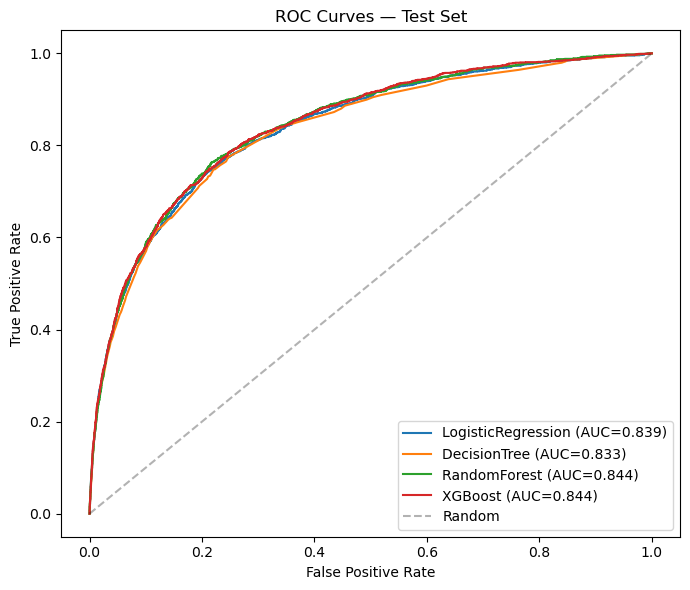

In [72]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, pipe in best_models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, proba)
    auc = test_results[name]['AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

Best model: XGBoost
[[19624  2739]
 [  616  1055]]
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     22363
           1       0.28      0.63      0.39      1671

    accuracy                           0.86     24034
   macro avg       0.62      0.75      0.65     24034
weighted avg       0.92      0.86      0.88     24034



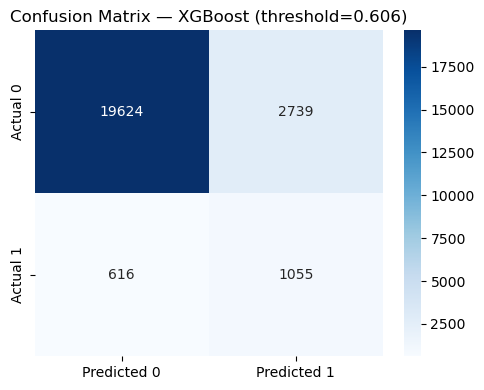

In [74]:
# confusion matrix + full report for the best model (by AUC)
best = final_table['AUC'].idxmax()
print("Best model:", best)

proba = best_models[best].predict_proba(X_test)[:, 1]
pred = (proba >= thresholds[best]).astype(int)

print(confusion_matrix(Y_test, pred))
print(classification_report(Y_test, pred))

import seaborn as sns

pred_best = (proba_best >= thresholds[best]).astype(int)
cm = confusion_matrix(Y_test, pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title(f"Confusion Matrix — {best} (threshold={thresholds[best]:.3f})")
plt.tight_layout()
plt.show()


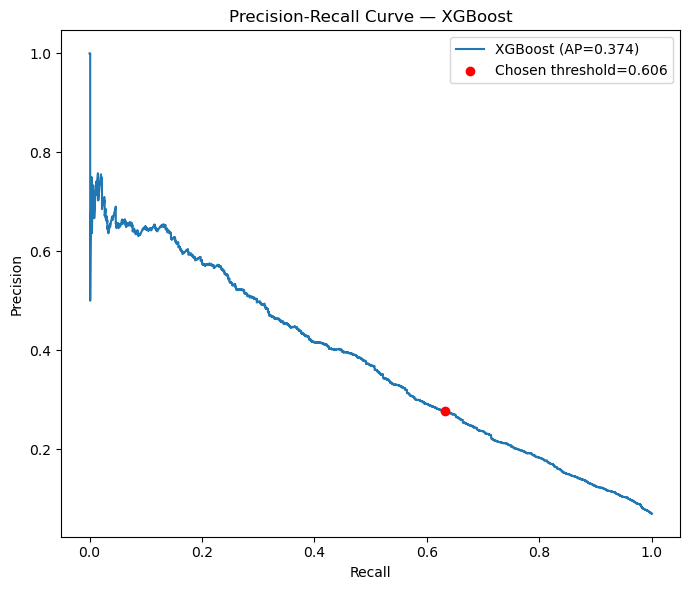

In [73]:
from sklearn.metrics import precision_recall_curve, average_precision_score

proba_best = best_models[best].predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(Y_test, proba_best)
ap = average_precision_score(Y_test, proba_best)

# find the point on the curve closest to your chosen threshold
idx = np.argmin(np.abs(thr - thresholds[best]))

plt.figure(figsize=(7, 6))
plt.plot(rec, prec, label=f"{best} (AP={ap:.3f})")
plt.scatter(rec[idx], prec[idx], color='red', zorder=5,
            label=f"Chosen threshold={thresholds[best]:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best}")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# generic importance extractor — works for linear (coef_) and tree/boosting (feature_importances_) models
def get_importance(pipe, feature_names):
    m = pipe.named_steps['m']
    if hasattr(m, 'feature_importances_'):
        vals = m.feature_importances_
    elif hasattr(m, 'coef_'):
        vals = np.abs(m.coef_).ravel()   # magnitude only — sign shown separately for LR
    else:
        raise ValueError(f"Model {type(m)} has neither feature_importances_ nor coef_")
    return pd.Series(vals, index=feature_names).sort_values(ascending=False)

feature_names = X_train.columns
importances = {name: get_importance(pipe, feature_names) for name, pipe in best_models.items()}

In [69]:
# top 15 features for each model, side by side
for name, imp in importances.items():
    print(f"\n{'='*40}\n{name} — top 15 features\n{'='*40}")
    print(imp.head(15).round(4))


LogisticRegression — top 15 features
is_coded                                1.1500
NumberOfTimes90DaysLate                 0.7980
RevolvingUtilizationOfUnsecuredLines    0.6975
NumberOfTime30-59DaysPastDueNotWorse    0.4844
NumberOfTime60-89DaysPastDueNotWorse    0.4818
age                                     0.2708
NumberOfOpenCreditLinesAndLoans         0.1937
MonthlyIncome                           0.1648
NumberRealEstateLoansOrLines            0.1052
dr_bin_9.0                              0.0750
dr_bin_4.0                              0.0529
dr_bin_0.0                              0.0498
NumberOfDependents                      0.0466
dr_bin_5.0                              0.0430
dr_bin_3.0                              0.0372
dtype: float64

DecisionTree — top 15 features
RevolvingUtilizationOfUnsecuredLines    0.5424
NumberOfTime30-59DaysPastDueNotWorse    0.1888
NumberOfTimes90DaysLate                 0.1553
NumberOfTime60-89DaysPastDueNotWorse    0.0523
age                   

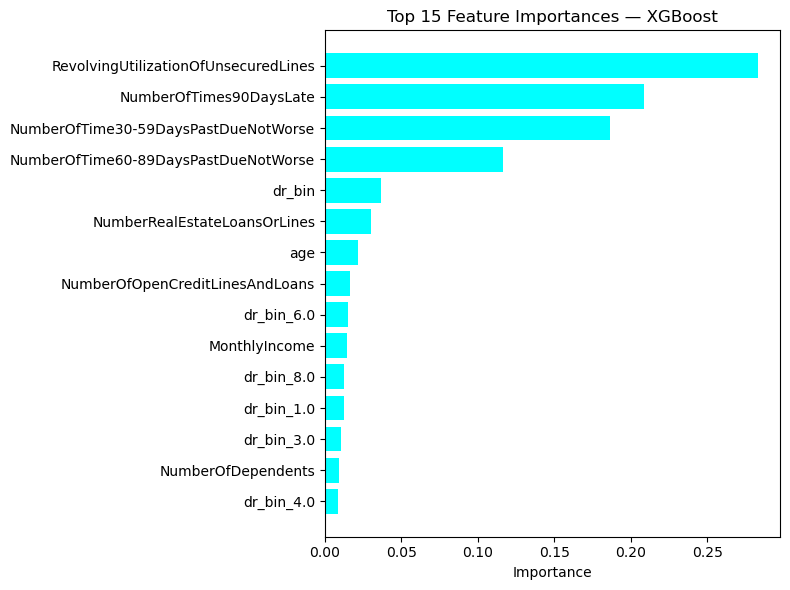

In [70]:
# bar chart for the overall best model (by AUC, from final_table)
top_n = 15
best_imp = importances[best].head(top_n).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(best_imp.index, best_imp.values, color="cyan")
plt.title(f"Top {top_n} Feature Importances — {best}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()